In [69]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler
from DataMetaMap.visualization.plots import EmbeddingVisualizer

from DataMetaMap.embedders.dataset2vec.config import Dataset2VecConfig, OptimizerConfig
from DataMetaMap.embedders.dataset2vec.model import Dataset2Vec
from DataMetaMap.embedders.dataset2vec.loader import (
    Dataset2VecLoader,
    RepeatableDataset2VecLoader,
)

DATASET_TYPES = ["circles", "moons", "blobs"]

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def apply_noise(X: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
    noise_scale = rng.uniform(0.05, 0.3)
    return X + rng.randn(*X.shape) * noise_scale


def generate_single_dataset(
    M: int = 2,
    rng: np.random.RandomState = None,
) -> tuple[np.ndarray, np.ndarray, str]:
    if rng is None:
        rng = np.random.RandomState()

    s = int(rng.uniform(0, 100))
    q = rng.choice([7, 8, 9])
    N = 2 ** q
    ds_type = rng.choice(DATASET_TYPES)

    if ds_type == "circles":
        X, y = make_circles(
            n_samples=N, noise=0.05,
            factor=rng.uniform(0.3, 0.7),
            random_state=s,
        )
    elif ds_type == "moons":
        X, y = make_moons(n_samples=N, noise=0.05, random_state=s)
    else:
        X, y = make_blobs(
            n_samples=N, centers=3,
            n_features=M, random_state=s,
        )

    if rng.uniform(0, 1) < 0.5:
        X = apply_noise(X, rng)

    X = StandardScaler().fit_transform(X)
    return X, y, ds_type


def generate_meta_dataset(
    n_datasets: int = 10000,
    M: int = 2,
    subset_size: int = 200,
    random_state: int = 42,
    verbose: bool = True,
) -> tuple[list[pd.DataFrame], list[str]]:
    rng        = np.random.RandomState(random_state)
    dataframes = []
    ds_types   = []
    counts     = {"circles": 0, "moons": 0, "blobs": 0}

    for i in range(n_datasets):
        if verbose and (i + 1) % 1000 == 0:
            print(f"  Сгенерировано: {i + 1}/{n_datasets}")

        X, y, ds_type = generate_single_dataset(M=M, rng=rng)

        if len(X) > subset_size:
            idx  = rng.choice(len(X), size=subset_size, replace=False)
            X, y = X[idx], y[idx]

        df = pd.DataFrame(X, columns=[f"x{j}" for j in range(M)])
        df["target"] = y.astype(float)

        dataframes.append(df)
        ds_types.append(ds_type)
        counts[ds_type] += 1

    if verbose:
        print(f"\n  circles={counts['circles']}, "
              f"moons={counts['moons']}, blobs={counts['blobs']}")

    return dataframes, ds_types

N_TOTAL = 10000
N_TRAIN = 8000
N_VAL   = 1000
N_TEST  = 1000

all_dfs, all_types = generate_meta_dataset(
    n_datasets=N_TOTAL, M=2, subset_size=200,
    random_state=42, verbose=True,
)

train_dfs  = all_dfs[:N_TRAIN]
val_dfs    = all_dfs[N_TRAIN:N_TRAIN + N_VAL]
test_dfs   = all_dfs[N_TRAIN + N_VAL:]
test_types = all_types[N_TRAIN + N_VAL:]


Index(['x0', 'x1', 'target'], dtype='object')

  circles=0, moons=0, blobs=0


In [56]:
train_loader = RepeatableDataset2VecLoader(
    batch_size=32,
    n_batches=100,
).load(train_dfs)

val_loader = RepeatableDataset2VecLoader(
    batch_size=32,
    n_batches=20,
).load(val_dfs)

In [57]:
model_config = Dataset2VecConfig(
        f_dense_hidden_size=16,
        f_res_hidden_size=16,
        f_res_n_layers=3, 
        f_block_repetitions=3,
        f_out_size=32,
        g_layers_sizes=[16, 8, 8],
        h_dense_hidden_size=8,
        h_res_hidden_size=16,
        h_res_n_layers=3,
        h_block_repetitions=3,
        output_size=16,
    )

optimizer_config = OptimizerConfig(
    gamma=1.0,
    learning_rate=3e-4,
    weight_decay=1e-4,
)

In [58]:
model = Dataset2Vec(config=model_config, optimizer_config=optimizer_config)

In [59]:
class MetricsCallback(pl.Callback):

    def __init__(self):
        self.train_loss:     list[float] = []
        self.val_loss:       list[float] = []
        self.train_accuracy: list[float] = []
        self.val_accuracy:   list[float] = []
        self._sanity_check_done = False

    def on_train_epoch_end(self, trainer, pl_module):
        self._sanity_check_done = True
        m = trainer.callback_metrics
        if "train_loss"     in m: self.train_loss.append(m["train_loss"].item())
        if "train_accuracy" in m: self.train_accuracy.append(m["train_accuracy"].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        if not self._sanity_check_done:
            return
        m = trainer.callback_metrics
        if "val_loss"     in m: self.val_loss.append(m["val_loss"].item())
        if "val_accuracy" in m: self.val_accuracy.append(m["val_accuracy"].item())

metrics_cb = MetricsCallback()

In [60]:
trainer = pl.Trainer(
        max_epochs=10,
        callbacks=[metrics_cb],
        enable_progress_bar=True,
        log_every_n_steps=1,
        enable_checkpointing=False,
    )

trainer.fit(model, train_loader, val_loader)

GPU available: True (mps), used: True
GPU available: True (mps), used: True
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
IPU available: False, using: 0 IPUs
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs

  | Name | Type       | Params
------------------------------------
0 | f    | Sequential | 3.0 K 
1 | g    | Sequential | 736   
2 | h    | Sequential | 1.9 K 
------------------------------------
5.6 K     Trainable params
0         Non-trainable params
5.6 K     Total params
0.023     Total estimated model params size (MB)

  | Name | Type       | Params
------------------------------------
0 | f    | Sequential | 3.0 K 
1 | g    | Sequential | 736   
2 | h    | Sequential | 1.9 K 
------------------------------------
5.6 K     Trainable

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
`Trainer.fit` stopped: `max_epochs=10` reached.
`Trainer.fit` stopped: `max_epochs=10` reached.


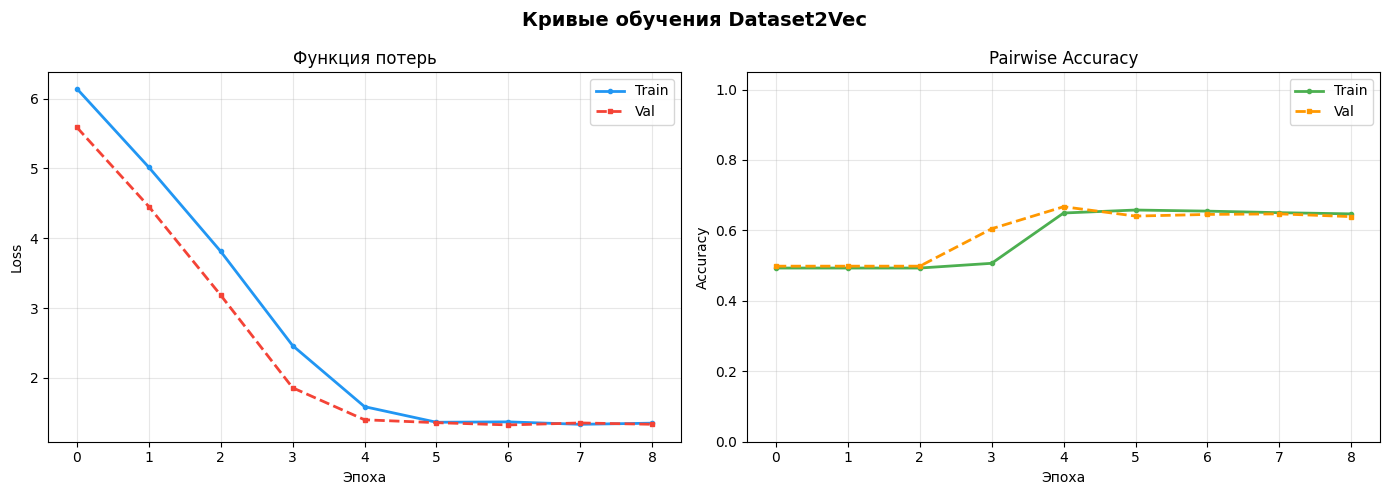

In [64]:
def plot_training_curves(callback, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Кривые обучения Dataset2Vec", fontsize=14, fontweight="bold")

    ax = axes[0]
    if callback.train_loss:
        ax.plot(range(len(callback.train_loss)), callback.train_loss,
                label="Train", color="#2196F3", linewidth=2, marker="o", markersize=3)
    if callback.val_loss:
        ax.plot(range(len(callback.val_loss)), callback.val_loss,
                label="Val", color="#F44336", linewidth=2, linestyle="--", marker="s", markersize=3)
    ax.set_xlabel("Эпоха"); ax.set_ylabel("Loss")
    ax.set_title("Функция потерь"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    if callback.train_accuracy:
        ax.plot(range(len(callback.train_accuracy)), callback.train_accuracy,
                label="Train", color="#4CAF50", linewidth=2, marker="o", markersize=3)
    if callback.val_accuracy:
        ax.plot(range(len(callback.val_accuracy)), callback.val_accuracy,
                label="Val", color="#FF9800", linewidth=2, linestyle="--", marker="s", markersize=3)
    ax.set_xlabel("Эпоха"); ax.set_ylabel("Accuracy")
    ax.set_title("Pairwise Accuracy"); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(metrics_cb)

  Эмбеддинг 50/300
  Эмбеддинг 100/300
  Эмбеддинг 150/300
  Эмбеддинг 200/300
  Эмбеддинг 250/300
  Эмбеддинг 300/300


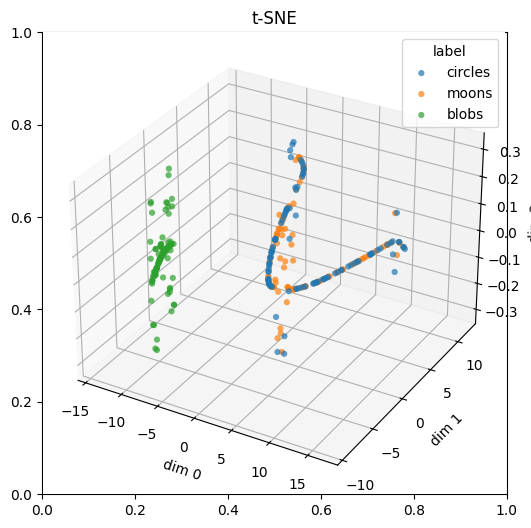

In [68]:
embeddings, labels = compute_test_embeddings(
    model=model, test_dfs=test_dfs,
    test_types=test_types, n_samples=300,
)

vis = EmbeddingVisualizer(random_state=42)
fig, ax = vis.plot(
    embeddings,
    labels=labels,
    method="tsne",
    title="t-SNE",
    n_components=3,
    show=True,
)

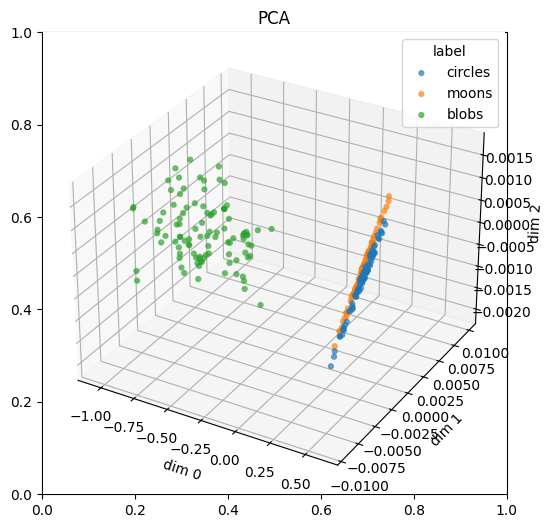

In [67]:
fig, ax = vis.plot(
    embeddings,
    labels=labels,
    method="pca",
    title="PCA",
    n_components=3,
    show=True,
)